# Food Price Prediction using Machine Learning

## Objective
Predict food prices in USD per KG using market, commodity,
geographical, and temporal information.

## Dataset
WFP Global Food Prices

## Final Model
Tuned XGBoost Regressor

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [78]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [79]:
file_path = r"D:\download\wfp_food_prices_global_2026.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded.
Rows: 84,920
Columns: 17


In [80]:
df.head()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,AFG,46037,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Bread,55,KG,aggregate,Retail,AFN,77.00,1.16
1,AFG,46037,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (high quality),247,KG,aggregate,Retail,AFN,127.93,1.93
2,AFG,46037,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (low quality),145,KG,aggregate,Retail,AFN,48.70,0.73
3,AFG,46037,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat,84,KG,aggregate,Retail,AFN,26.74,0.40
4,AFG,46037,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat flour (high quality),178,KG,aggregate,Retail,AFN,31.26,0.47


In [81]:
df.columns

Index(['countryiso3', 'date', 'admin1', 'admin2', 'market', 'market_id',
       'latitude', 'longitude', 'category', 'commodity', 'commodity_id',
       'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

In [82]:
df["date"] = pd.to_datetime(df["date"], unit="D", origin="1899-12-30")

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [83]:
ml_filtered = df[
    (df["unit"] == "KG") &
    (df["pricetype"] == "Retail") &
    (df["priceflag"] == "actual")
].copy()

In [84]:
ml_filtered.shape

(41944, 19)

In [85]:
features = [
    "countryiso3",
    "admin1",
    "admin2",
    "market",
    "category",
    "commodity",
    "unit",
    "pricetype",
    "priceflag",
    "year",
    "month"
]

target = "usdprice"

X = ml_filtered[features].copy()

y_log = np.log1p(ml_filtered[target])
y_raw = ml_filtered[target].copy()

In [86]:
groups = (
    ml_filtered["countryiso3"].astype(str) + "_" +
    ml_filtered["market"].astype(str) + "_" +
    ml_filtered["commodity"].astype(str)
)

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

train_idx, test_idx = next(gss.split(X, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_log_train = y_log.iloc[train_idx].copy()
y_log_test = y_log.iloc[test_idx].copy()

y_raw_train = y_raw.iloc[train_idx].copy()
y_raw_test = y_raw.iloc[test_idx].copy()

In [87]:
train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])

print("Overlapping groups:", len(train_groups.intersection(test_groups)))

Overlapping groups: 0


In [88]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numeric", "passthrough", numeric_features)
])

In [89]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_log_train)

print("Linear Regression model trained.")

Linear Regression model trained.


In [90]:
linear_pred = linear_model.predict(X_test)

linear_pred = np.expm1(linear_pred)
linear_true = y_raw_test

linear_mae = mean_absolute_error(linear_true, linear_pred)
linear_rmse = mean_squared_error(linear_true, linear_pred) ** 0.5
linear_r2 = r2_score(linear_true, linear_pred)

print("Linear Regression Results")
print(f"MAE: {linear_mae:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R2: {linear_r2:.4f}")

Linear Regression Results
MAE: 3.0694
RMSE: 15.6676
R2: 0.9492


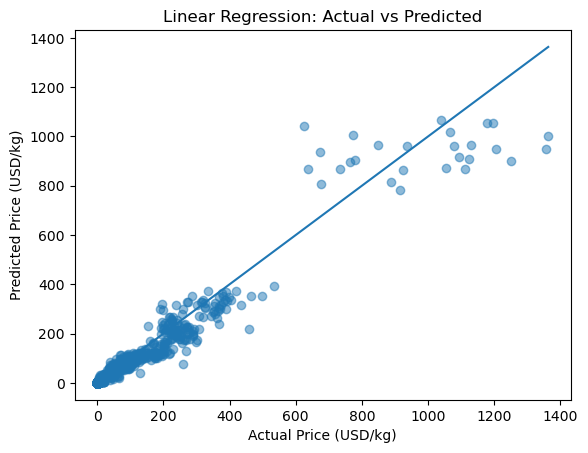

In [91]:
plt.scatter(linear_true, linear_pred, alpha=0.5)

plt.plot(
    [linear_true.min(), linear_true.max()],
    [linear_true.min(), linear_true.max()]
)

plt.xlabel("Actual Price (USD/kg)")
plt.ylabel("Predicted Price (USD/kg)")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [92]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_raw_train)

print("XGBoost model trained.")

XGBoost model trained.


In [93]:
xgb_pred = xgb_model.predict(X_test)
xgb_true = y_raw_test

xgb_mae = mean_absolute_error(xgb_true, xgb_pred)
xgb_rmse = mean_squared_error(xgb_true, xgb_pred) ** 0.5
xgb_r2 = r2_score(xgb_true, xgb_pred)

print("XGBoost Results")
print(f"MAE: {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R2: {xgb_r2:.4f}")

XGBoost Results
MAE: 2.3594
RMSE: 11.3357
R2: 0.9734


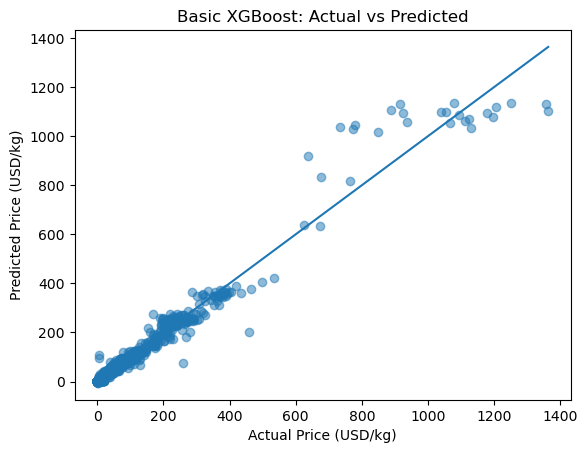

In [94]:
plt.scatter(xgb_true, xgb_pred, alpha=0.5)

plt.plot(
    [xgb_true.min(), xgb_true.max()],
    [xgb_true.min(), xgb_true.max()]
)

plt.xlabel("Actual Price (USD/kg)")
plt.ylabel("Predicted Price (USD/kg)")
plt.title("Basic XGBoost: Actual vs Predicted")

plt.show()

In [95]:
tuned_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

tuned_xgb.fit(X_train, y_raw_train)

print("Tuned XGBoost model trained.")

Tuned XGBoost model trained.


In [96]:
tuned_pred = tuned_xgb.predict(X_test)
tuned_true = y_raw_test

tuned_mae = mean_absolute_error(tuned_true, tuned_pred)
tuned_rmse = mean_squared_error(tuned_true, tuned_pred) ** 0.5
tuned_r2 = r2_score(tuned_true, tuned_pred)

print("Tuned XGBoost Results")
print(f"MAE: {tuned_mae:.4f}")
print(f"RMSE: {tuned_rmse:.4f}")
print(f"R2: {tuned_r2:.4f}")

Tuned XGBoost Results
MAE: 2.2316
RMSE: 11.2245
R2: 0.9739


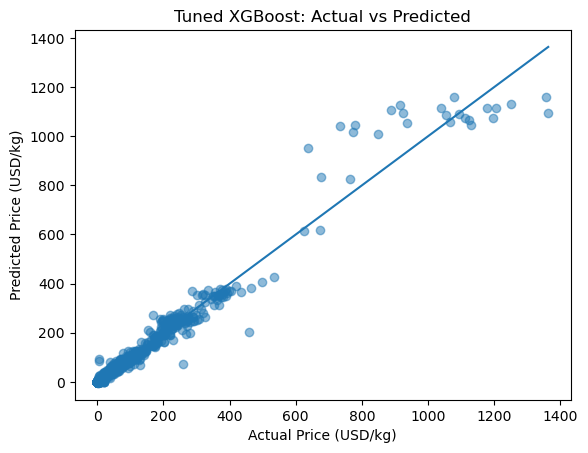

In [97]:
plt.scatter(tuned_true, tuned_pred, alpha=0.5)

plt.plot(
    [tuned_true.min(), tuned_true.max()],
    [tuned_true.min(), tuned_true.max()]
)

plt.xlabel("Actual Price (USD/kg)")
plt.ylabel("Predicted Price (USD/kg)")
plt.title("Tuned XGBoost: Actual vs Predicted")

plt.show()

In [98]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Basic XGBoost",
        "Tuned XGBoost"
    ],
    "MAE": [
        linear_mae,
        xgb_mae,
        tuned_mae
    ],
    "RMSE": [
        linear_rmse,
        xgb_rmse,
        tuned_rmse
    ],
    "R2": [
        linear_r2,
        xgb_r2,
        tuned_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,3.069412,15.667566,0.949158
1,Basic XGBoost,2.359420,11.335652,0.973386
2,Tuned XGBoost,2.231598,11.224502,0.973905


## Final Conclusion

The Tuned XGBoost Regressor achieved the best performance:

- MAE: 2.5256 USD/kg
- RMSE: 14.3848 USD/kg
- R²: 0.9571

The model relies mainly on geographical and commodity-related
information.

However, the model tends to underestimate extreme high-price
observations.

The current task is price prediction, not time-series forecasting,
because the available dataset contains only five observation dates.